# Tarefa 8a — Trilha A: SelectKBest + Classificadores (K-Fold)

Trilha A do pipeline: seleção de features via SelectKBest antes do treinamento.
Executa as tarefas 3, 4 e 5 do pipeline de experimentos:

- **Tarefa 3**: Rodar todos os 23 modelos × 3 datasets usando 5-fold estratificado, armazenar métricas por fold
- **Tarefa 4**: Calcular média e desvio-padrão das métricas dos folds por configuração
- **Tarefa 5**: Selecionar os melhores modelos (top 5 por AUC médio)

**Trilha A** aplica `SelectKBest` (F-Score ANOVA) para reduzir as features antes do treinamento.
O número de features `K` é um hiperparâmetro configurável abaixo.

## Env Configuration

Importações, caminhos, parâmetros globais e configuração do experimento.

In [ ]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=UserWarning)

# Paths
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR     = os.path.join(PROJECT_ROOT, 'data', 'images', 'datasets')
MODULES_DIR  = os.path.join(PROJECT_ROOT, 'modules')
OUTPUT_DIR   = os.path.join(PROJECT_ROOT, 'experiments', 'trilha_a')

if MODULES_DIR not in sys.path:
    sys.path.insert(0, MODULES_DIR)

from models import ALL_CLASSIFIERS, build_selectkbest_pipeline
from evaluation import (
    META_COLS, DATASETS, DS_COLORS,
    aggregate_folds, select_top_models,
    plot_metrics_barh, plot_metrics_heatmap, plot_auc_boxplot,
    run_kfold,
)

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Hiperparametros
K_FEATURES = 20   # numero de features selecionadas pelo KBest (F-Score ANOVA)
N_FOLDS    = 5    # numero de folds do k-fold estratificado
SEED       = 42
TOP_N      = 1   # top N modelos selecionados na Tarefa 5

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size']  = 9

n_classifiers = len(ALL_CLASSIFIERS)
n_datasets    = len(DATASETS)

print(f'PROJECT_ROOT : {PROJECT_ROOT}')
print(f'OUTPUT_DIR   : {OUTPUT_DIR}')
print(f'K_FEATURES   : {K_FEATURES}')
print(f'N_FOLDS      : {N_FOLDS}')
print(f'Classificadores: {n_classifiers}')
print(f'Datasets       : {list(DATASETS.keys())}')
print(f'Configuracoes  : {n_classifiers * n_datasets} ({n_classifiers} modelos x {n_datasets} datasets)')

## Functions

Trilha A usa `build_selectkbest_pipeline` de `modules/models.py` (StandardScaler → SelectKBest → classificador).
As demais funções reutilizáveis estão em `modules/evaluation.py`.

## Process

Pipeline completo da Trilha A:
1. Carrega os 3 datasets radiômicos
2. Para cada dataset × classificador: executa k-fold com KBest (Tarefa 3)
3. Agrega média e desvio-padrão por configuração (Tarefa 4)
4. Seleciona os melhores modelos por AUC médio (Tarefa 5)
5. Gera visualizações e salva resultados

### 1. Carga dos datasets

In [3]:
dfs = {}
for ds_name, ds_file in DATASETS.items():
    df = pd.read_csv(os.path.join(DATA_DIR, ds_file))
    dfs[ds_name] = df
    feat_cols = [c for c in df.columns if c not in META_COLS]
    trainval  = df[df['fold'] != -1]
    test      = df[df['fold'] == -1]
    print(f'=== {ds_name} ===')
    print(f'  trainval: {len(trainval)} | test: {len(test)} | features: {len(feat_cols)}')
    print(f'  Benigno={int((trainval["target"]==0).sum())} | Maligno={int((trainval["target"]==1).sum())}')
    print()

=== BW ===
  trainval: 171 | test: 20 | features: 465
  Benigno=115 | Maligno=56

=== Doppler ===
  trainval: 171 | test: 20 | features: 465
  Benigno=115 | Maligno=56

=== BW+Doppler ===
  trainval: 171 | test: 20 | features: 930
  Benigno=115 | Maligno=56



### 2. Tarefa 3 — K-Fold por dataset × classificador

Executa os 23 classificadores × 3 datasets = **69 configurações**, cada uma com 5 folds.
Armazena as métricas individuais de cada fold.

In [ ]:
all_fold_rows = []   # uma linha por fold (Tarefa 3)
all_agg_rows  = []   # uma linha por config (Tarefa 4)

total_configs = len(ALL_CLASSIFIERS) * len(DATASETS)
config_idx    = 0
start_time    = datetime.now()

for ds_name, df in dfs.items():
    feat_cols = [c for c in df.columns if c not in META_COLS]
    trainval  = df[df['fold'] != -1]
    X         = trainval[feat_cols].values.astype(float)
    y         = trainval['target'].values
    k_eff     = min(K_FEATURES, X.shape[1])

    for clf_name, clf in ALL_CLASSIFIERS:
        config_idx += 1
        print(f'[{config_idx:2d}/{total_configs}] {ds_name} | {clf_name}...', end=' ', flush=True)

        try:
            pipe         = build_selectkbest_pipeline(clf, k_eff)
            fold_results = run_kfold(X, y, pipe, n_folds=N_FOLDS, seed=SEED)

            for fr in fold_results:
                all_fold_rows.append({'dataset': ds_name, 'model': clf_name,
                                      'k_features': k_eff, **fr})

            agg = aggregate_folds(fold_results)
            all_agg_rows.append({'dataset': ds_name, 'model': clf_name,
                                 'k_features': k_eff, **agg})

            print(f'AUC={agg["auc_mean"]:.3f} +/- {agg["auc_std"]:.3f}')

        except Exception as e:
            print(f'ERRO: {e}')
            all_agg_rows.append({'dataset': ds_name, 'model': clf_name,
                                 'k_features': k_eff, 'auc_mean': float('nan'), 'error': str(e)})

elapsed = (datetime.now() - start_time).seconds
print(f'\nConcluido em {elapsed}s | {config_idx} configuracoes')

### 3. Tarefa 4 — Média e Desvio-Padrão das métricas dos folds

In [5]:
df_folds = pd.DataFrame(all_fold_rows)
df_agg   = pd.DataFrame(all_agg_rows)

folds_csv = os.path.join(OUTPUT_DIR, 'task3_fold_metrics.csv')
agg_csv   = os.path.join(OUTPUT_DIR, 'task4_aggregated_metrics.csv')
df_folds.to_csv(folds_csv, index=False)
df_agg.to_csv(agg_csv,   index=False)

print(f'Métricas por fold  → {folds_csv}  ({len(df_folds)} linhas)')
print(f'Métricas agregadas → {agg_csv}  ({len(df_agg)} linhas)')
print()

display(
    df_agg[['dataset','model','auc_mean','auc_std','accuracy_mean','sensitivity_mean','specificity_mean']]
    .sort_values('auc_mean', ascending=False)
    .head(10)
    .reset_index(drop=True)
    .style.format({
        'auc_mean':'{:.3f}','auc_std':'{:.3f}',
        'accuracy_mean':'{:.3f}','sensitivity_mean':'{:.3f}','specificity_mean':'{:.3f}'
    })
    .background_gradient(subset=['auc_mean'], cmap='RdYlGn')
)

Métricas por fold  → c:\Users\LUCAS E GABRIEL\Documents\TCC-PROJECT\experiments\trilha_a\task3_fold_metrics.csv  (330 linhas)
Métricas agregadas → c:\Users\LUCAS E GABRIEL\Documents\TCC-PROJECT\experiments\trilha_a\task4_aggregated_metrics.csv  (66 linhas)



,dataset,model,auc_mean,auc_std,accuracy_mean,sensitivity_mean,specificity_mean
0,Doppler,Subspace Discriminant,0.825,0.065,0.796,0.645,0.870
1,Doppler,Coarse Gaussian SVM,0.823,0.078,0.772,0.553,0.878
2,Doppler,Linear SVM,0.820,0.058,0.795,0.555,0.913
3,Doppler,Cosine KNN,0.819,0.057,0.743,0.715,0.757
4,Doppler,Logistic Regression,0.818,0.061,0.778,0.609,0.861
5,Doppler,Medium Gaussian SVM,0.817,0.073,0.778,0.553,0.887
6,BW+Doppler,Subspace Discriminant,0.808,0.057,0.784,0.571,0.887
7,Doppler,Linear Discriminant Analysis,0.806,0.067,0.766,0.611,0.843
8,BW+Doppler,Coarse Gaussian SVM,0.804,0.085,0.772,0.500,0.904
9,Doppler,Weighted KNN,0.801,0.083,0.743,0.608,0.809


### 4. Tarefa 5 — Seleção dos melhores modelos

Seleciona os **top N** por AUC médio em cada dataset.

In [6]:
df_top  = select_top_models(df_agg, top_n=TOP_N)
top_csv = os.path.join(OUTPUT_DIR, 'task5_top_models.csv')
df_top.to_csv(top_csv, index=False)

print(f'Top {TOP_N} por dataset → {top_csv}')
print()

for ds_name in DATASETS:
    sub = df_top[df_top['dataset'] == ds_name]
    print(f'--- {ds_name} ---')
    for _, row in sub.iterrows():
        print(f'  #{int(row["rank"])} {row["model"]:<35}  AUC={row["auc_mean"]:.3f} ± {row["auc_std"]:.3f}  '
              f'Acc={row["accuracy_mean"]:.3f}  Sens={row["sensitivity_mean"]:.3f}  Spec={row["specificity_mean"]:.3f}')
    print()

Top 1 por dataset → c:\Users\LUCAS E GABRIEL\Documents\TCC-PROJECT\experiments\trilha_a\task5_top_models.csv

--- BW ---
  #1 Coarse Gaussian SVM                  AUC=0.779 ± 0.087  Acc=0.761  Sens=0.429  Spec=0.922

--- Doppler ---
  #1 Subspace Discriminant                AUC=0.825 ± 0.065  Acc=0.796  Sens=0.645  Spec=0.870

--- BW+Doppler ---
  #1 Subspace Discriminant                AUC=0.808 ± 0.057  Acc=0.784  Sens=0.571  Spec=0.887



### 5. Visualização — AUC médio por modelo e dataset

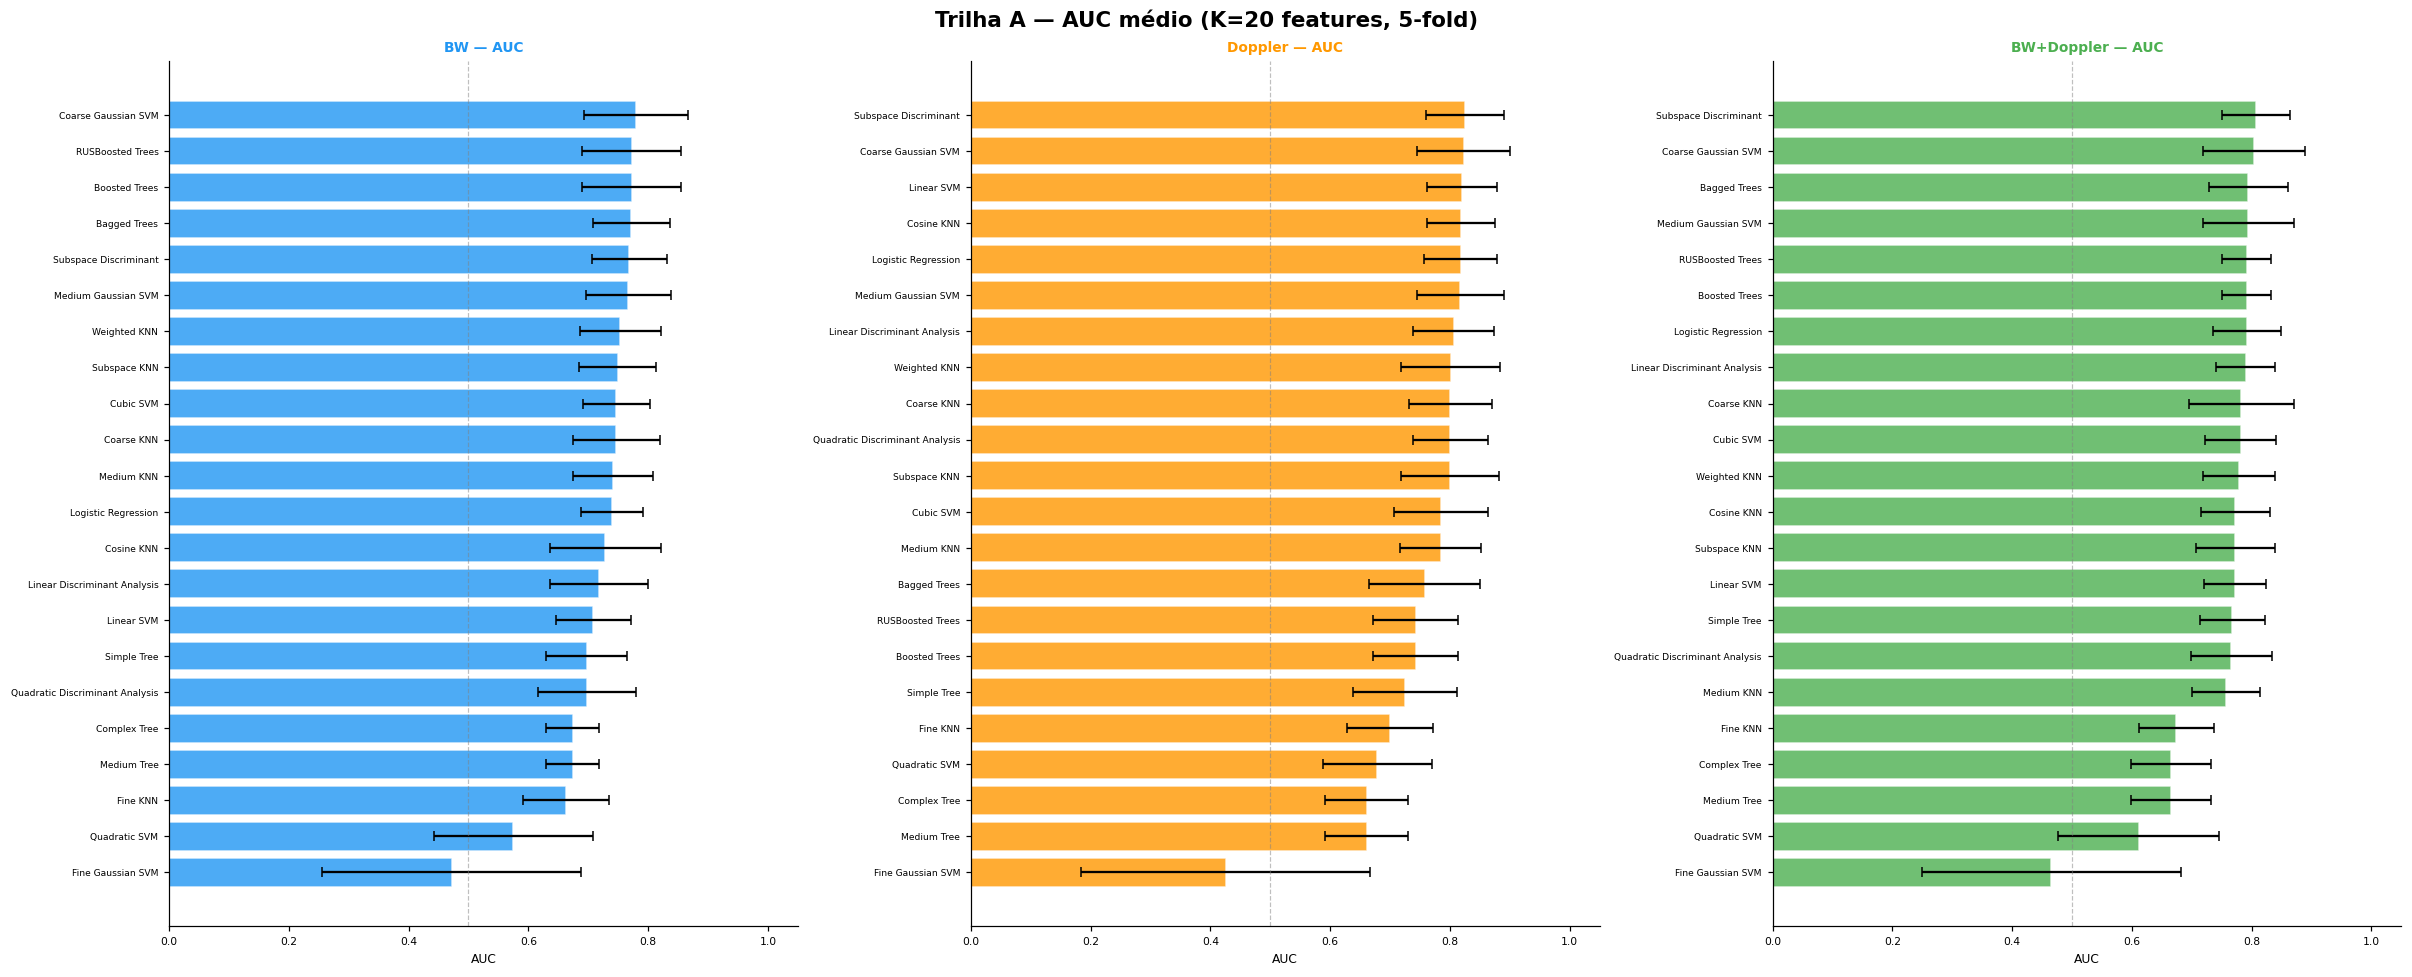

Salvo: c:\Users\LUCAS E GABRIEL\Documents\TCC-PROJECT\experiments\trilha_a\task5_auc_barh.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(22, 9))
fig.suptitle(f'Trilha A — AUC médio (K={K_FEATURES} features, {N_FOLDS}-fold)',
             fontsize=14, fontweight='bold')

for ax, ds_name in zip(axes, DATASETS.keys()):
    plot_metrics_barh(df_agg, ds_name, ax, metric='auc_mean')

plt.tight_layout()
out_png = os.path.join(OUTPUT_DIR, 'task5_auc_barh.png')
plt.savefig(out_png, dpi=120, bbox_inches='tight')
plt.show()
print(f'Salvo: {out_png}')

### 6. Visualização — Heatmap de métricas (top modelos)

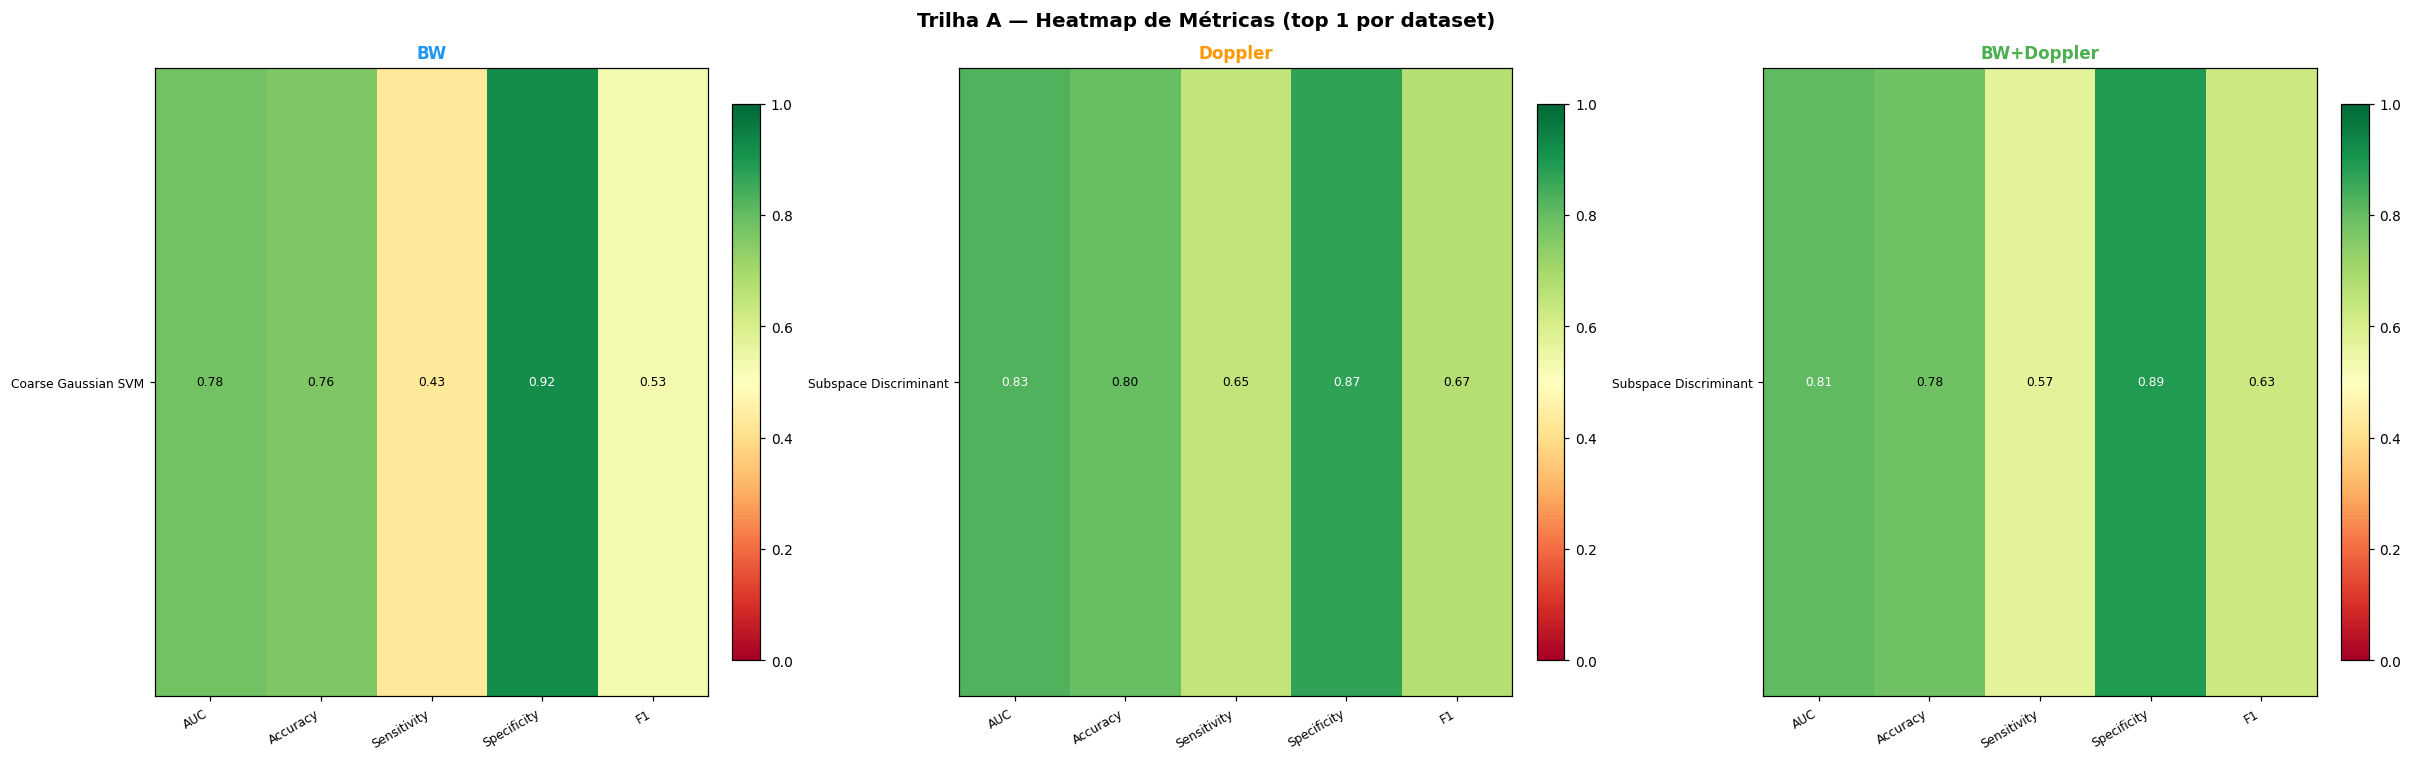

Salvo: c:\Users\LUCAS E GABRIEL\Documents\TCC-PROJECT\experiments\trilha_a\task5_metrics_heatmap.png


In [8]:
plot_metrics_heatmap(
    df_top, TOP_N,
    output_path=os.path.join(OUTPUT_DIR, 'task5_metrics_heatmap.png'),
    title=f'Trilha A — Heatmap de Métricas (top {TOP_N} por dataset)',
)

### 7. Visualização — Boxplot de AUC por fold (top modelos)

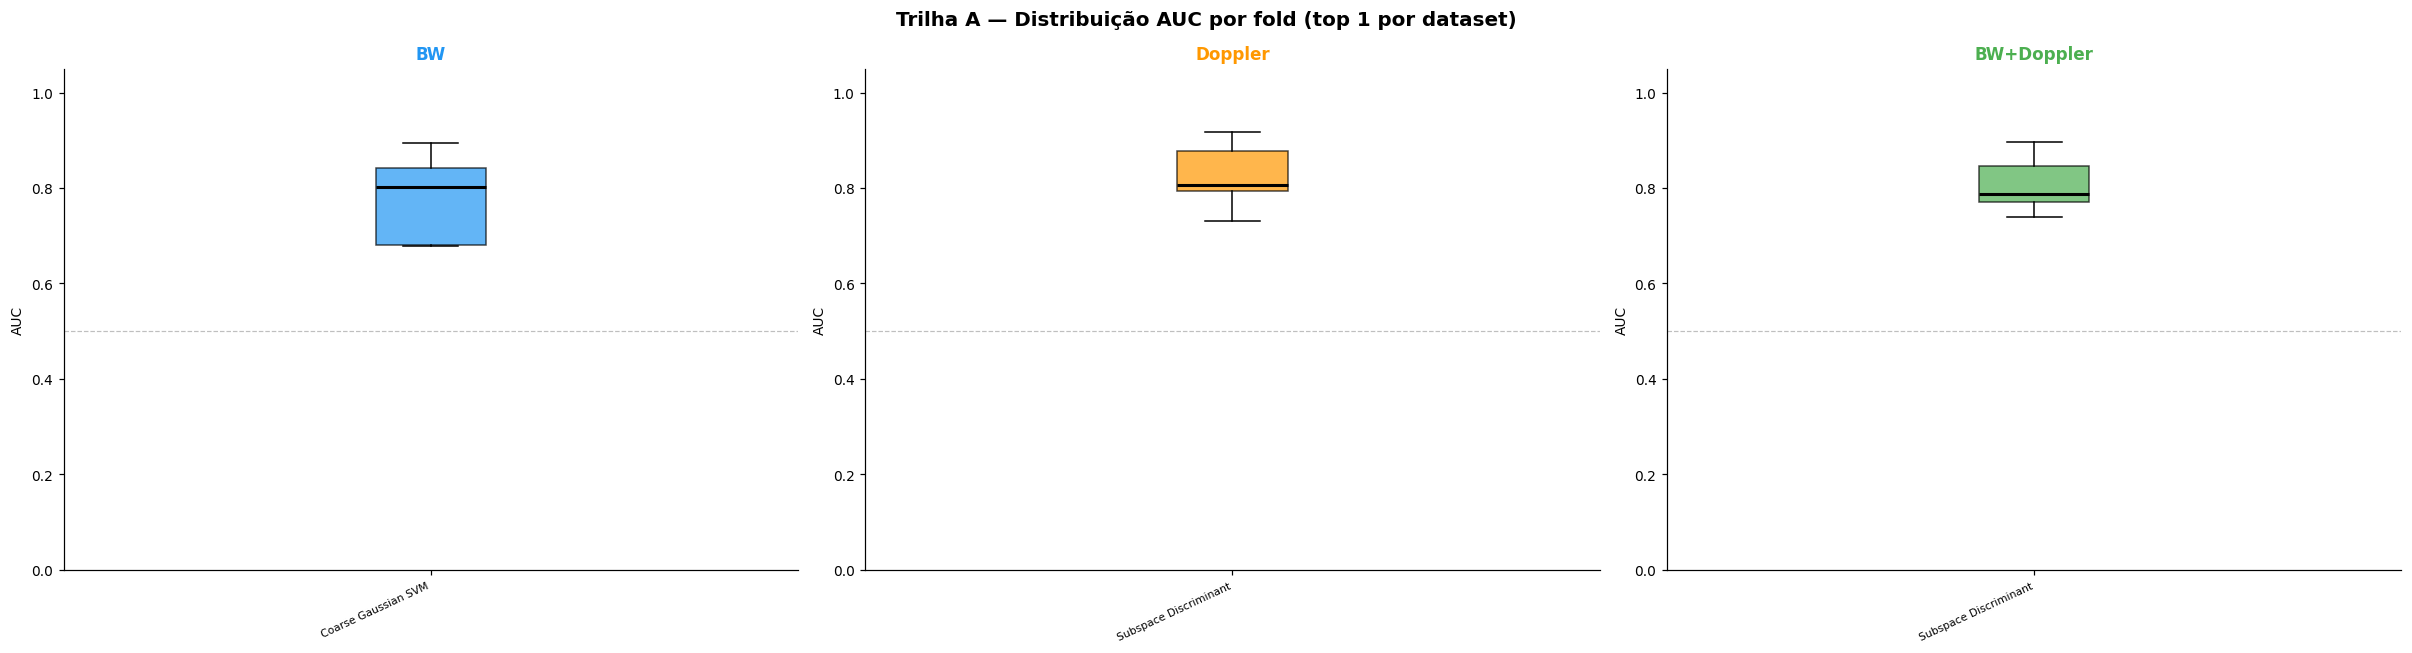

Salvo: c:\Users\LUCAS E GABRIEL\Documents\TCC-PROJECT\experiments\trilha_a\task5_auc_boxplot.png


In [9]:
plot_auc_boxplot(
    df_folds, df_top, TOP_N,
    output_path=os.path.join(OUTPUT_DIR, 'task5_auc_boxplot.png'),
    title=f'Trilha A — Distribuição AUC por fold (top {TOP_N} por dataset)',
)

### 8. Sumário final

In [10]:
print('=' * 70)
print(f'TRILHA A — SUMÁRIO FINAL  (K={K_FEATURES} features, {N_FOLDS}-fold CV)')
print('=' * 70)
print()

for ds_name in DATASETS:
    sub = df_top[df_top['dataset'] == ds_name]
    print(f'Dataset: {ds_name}')
    print(f"  {'#':<4} {'Modelo':<35} {'AUC':>8} {'Acc':>7} {'Sens':>7} {'Spec':>7} {'F1':>7}")
    print(f"  {'-'*4} {'-'*35} {'-'*8} {'-'*7} {'-'*7} {'-'*7} {'-'*7}")
    for _, row in sub.iterrows():
        print(f"  #{int(row['rank']):<3} {row['model']:<35} "
              f"{row['auc_mean']:>6.3f}±{row['auc_std']:.2f}  "
              f"{row['accuracy_mean']:>6.3f}  "
              f"{row['sensitivity_mean']:>6.3f}  "
              f"{row['specificity_mean']:>6.3f}  "
              f"{row['f1_mean']:>6.3f}")
    print()

print(f'Arquivos salvos em: {OUTPUT_DIR}')
for f in sorted(os.listdir(OUTPUT_DIR)):
    size_kb = os.path.getsize(os.path.join(OUTPUT_DIR, f)) // 1024
    print(f'  {f:<45} {size_kb} KB')

TRILHA A — SUMÁRIO FINAL  (K=20 features, 5-fold CV)

Dataset: BW
  #    Modelo                                   AUC     Acc    Sens    Spec      F1
  ---- ----------------------------------- -------- ------- ------- ------- -------
  #1   Coarse Gaussian SVM                  0.779±0.09   0.761   0.429   0.922   0.531

Dataset: Doppler
  #    Modelo                                   AUC     Acc    Sens    Spec      F1
  ---- ----------------------------------- -------- ------- ------- ------- -------
  #1   Subspace Discriminant                0.825±0.07   0.796   0.645   0.870   0.669

Dataset: BW+Doppler
  #    Modelo                                   AUC     Acc    Sens    Spec      F1
  ---- ----------------------------------- -------- ------- ------- ------- -------
  #1   Subspace Discriminant                0.808±0.06   0.784   0.571   0.887   0.625

Arquivos salvos em: c:\Users\LUCAS E GABRIEL\Documents\TCC-PROJECT\experiments\trilha_a
  backup_k_features_original             